# 📊 Retail Analysis with RFM & Market Basket

## 1. 🧩 Problem Statement




Analyze retail transactions to uncover:

1.Sales trends and seasonality
2.Customer value and behavior
3.Product associations (items bought together)

🎯 Goal: Drive revenue via better targeting, retention, and cross-selling.

## Tools & Technologies
Python
Pandas
NumPy
Matplotlib & Seaborn
mlxtend (Apriori Algorithm)

## 2. 📂 Data Understanding

In [4]:
#upload csv file and import Pandas
import pandas as pd
df=pd.read_csv("online_retail.csv", encoding='latin1')

## 3. 🧹 Data Preparation


In [5]:

# Clean
df = df.dropna(subset=['CustomerID'])
df = df[df['Quantity'] > 0]

# Types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

# Feature
df['Revenue'] = df['Quantity'] * df['UnitPrice']

## 4. 📈 EDA (Sales & Products)

In [ ]:
#Monthly Revenue
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly = df.groupby(df['InvoiceDate'].dt.to_period('M'))['Revenue'].sum().reset_index()
monthly['InvoiceDate'] = monthly['InvoiceDate'].astype(str)

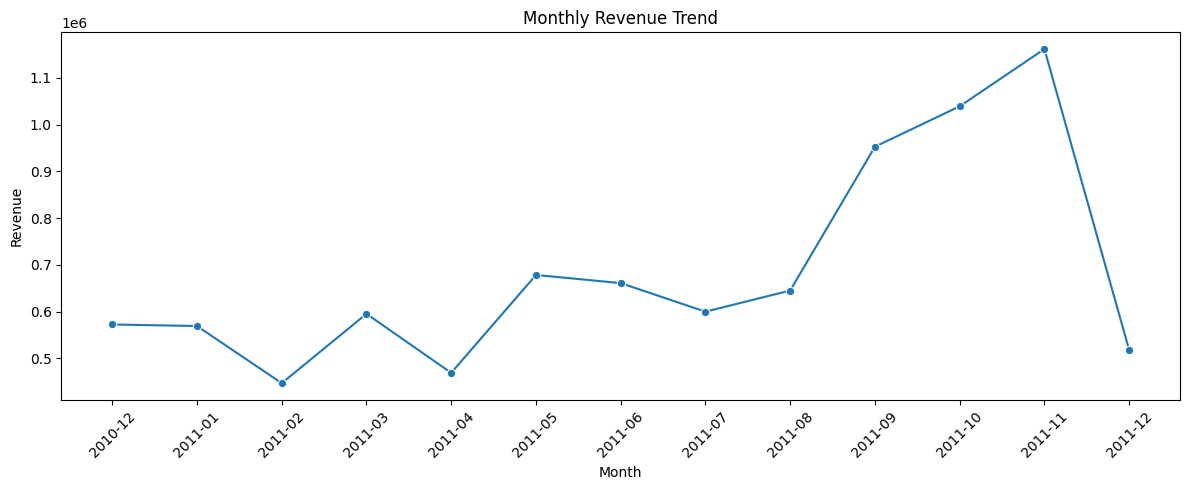

In [11]:
# 1. Monthly Revenue Trend (Line Chart)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
sns.lineplot(data=monthly_revenue, x='Month', y='Revenue', marker='o')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

### Sales Trends
Monthly revenue shows strong seasonal patterns
Peak sales observed during holiday periods

### Geographic Insights
Majority of sales originate from a few key regions

## 4.1 Top 10 Products (Bar Chart)

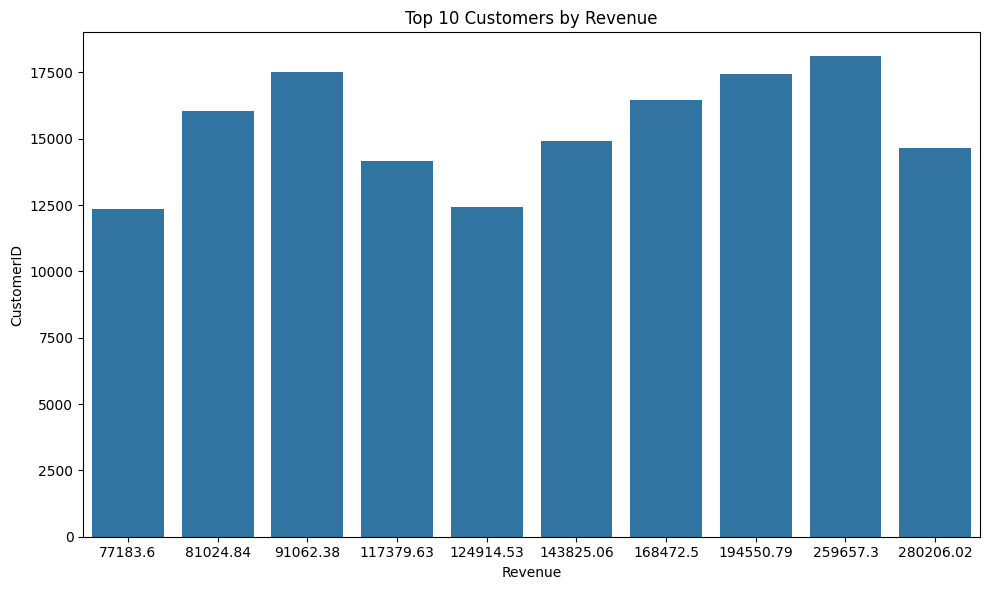

In [16]:
top_customers = (df.groupby('CustomerID')['Revenue']
                 .sum()
                 .sort_values(ascending=False)
                 .head(10)
                 .reset_index())

plt.figure(figsize=(10,6))
sns.barplot(data=top_customers, x='Revenue', y='CustomerID')
plt.title('Top 10 Customers by Revenue')
plt.tight_layout()
plt.show()

### Top Products
A small number of products contribute significantly to total sales

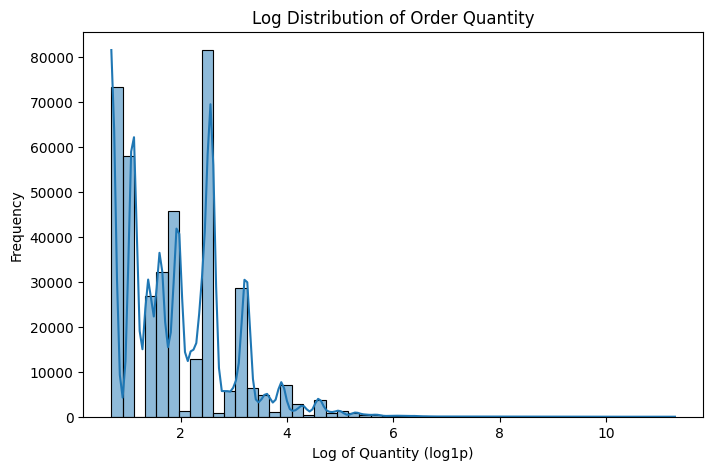

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(np.log1p(df['Quantity']), bins=50, kde=True)

plt.title('Log Distribution of Order Quantity')
plt.xlabel('Log of Quantity (log1p)')
plt.ylabel('Frequency')

plt.show()

#INSIGHTS 
#The distribution of order quantity is highly right-skewed, indicating that most customers purchase small quantities, while a few transactions involve bulk purchases.
Why log used:
A log transformation was applied to handle extreme outliers and better visualize the distribution.

Business Understanding:
The business serves both regular customers (small orders) and bulk buyers, which may represent wholesale or large-scale purchases.

##5. Order Size Distribution (Histogram)

In [27]:
top_countries = (df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10))

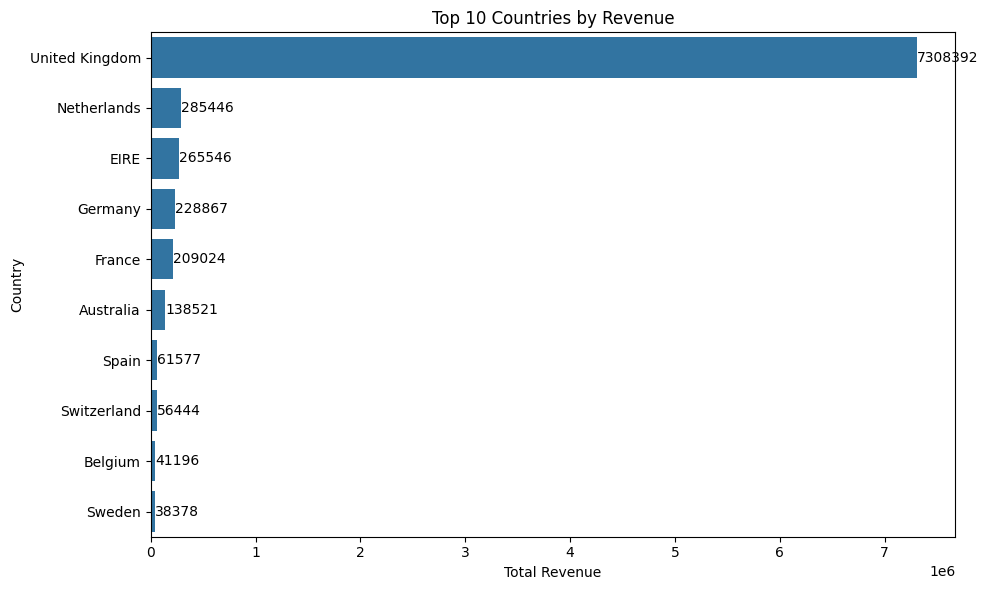

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 countries by revenue
top_countries = (
    df.groupby('Country')['Revenue']
      .sum()
      .sort_values(ascending=False)
      .head(10)
      .reset_index()
)

# Plot
plt.figure(figsize=(10,6))
ax = sns.barplot(data=top_countries, x='Revenue', y='Country')

# Add value labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f')

# Titles and labels
plt.title('Top 10 Countries by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')

plt.tight_layout()
plt.show()

In [34]:
#: Focus logistics/marketing on top regions.

## Customer Analysis

In [38]:
customer_rev = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
customer_rev = customer_rev.reset_index()
customer_rev.head(10)

,CustomerID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194550.79
3,16446.0,168472.50
4,14911.0,143825.06
5,12415.0,124914.53
6,14156.0,117379.63
7,17511.0,91062.38
8,16029.0,81024.84
9,12346.0,77183.60


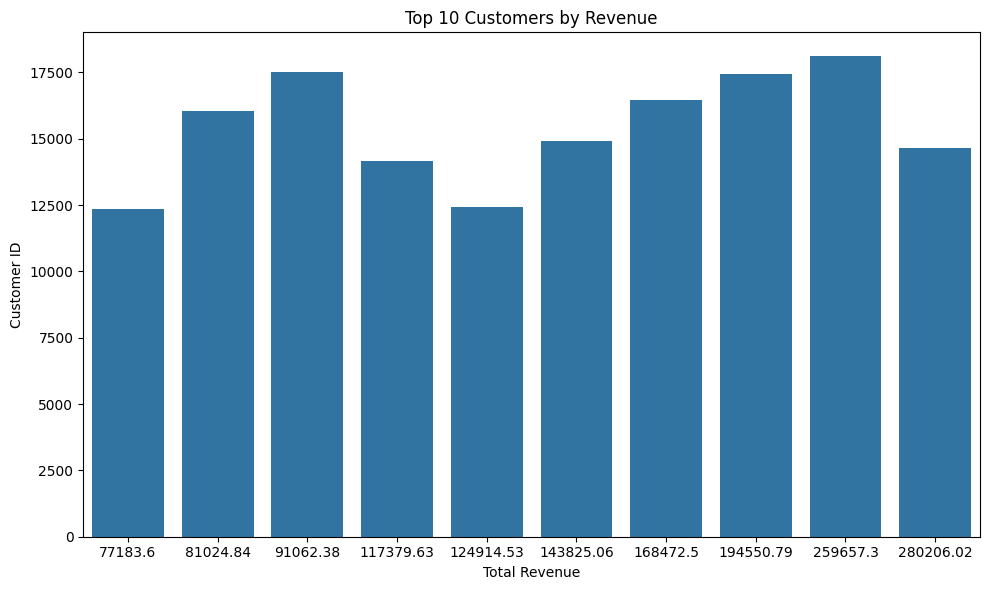

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

top_customers = customer_rev.head(10)

plt.figure(figsize=(10,6))
sns.barplot(data=top_customers, x='Revenue', y='CustomerID')

plt.title('Top 10 Customers by Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Customer ID')

plt.tight_layout()
plt.show()

In [40]:
customer_rev['Revenue'].describe()

count      4339.000000
mean       2053.793018
std        8988.248381
min           0.000000
25%         307.245000
50%         674.450000
75%        1661.640000
max      280206.020000
Name: Revenue, dtype: float64

In [42]:
total_revenue = customer_rev['Revenue'].sum()

top_10_revenue = customer_rev.head(10)['Revenue'].sum()

(top_10_revenue / total_revenue) * 100
print(total_revenue)


8911407.904


#A small number of customers contribute a large portion of total revenue, indicating a high dependency on key customers.

In [44]:
#Customers with  low spending
customer_rev.tail(10)

,CustomerID,Revenue
4329,16093.0,17.00
4330,17763.0,15.00
4331,13307.0,15.00
4332,15823.0,15.00
4333,16878.0,13.30
4334,17956.0,12.75
4335,16454.0,6.90
4336,14792.0,6.20
4337,16738.0,3.75
4338,13256.0,0.00


In [48]:
#Count high vs low value customers
#High value customers
customer_rev[customer_rev['Revenue'] > 10000].head()


,CustomerID,Revenue
0,14646.0,280206.02
1,18102.0,259657.30
2,17450.0,194550.79
3,16446.0,168472.50
4,14911.0,143825.06


In [49]:
#Low value customers
customer_rev[customer_rev['Revenue'] <= 10000].head()

,CustomerID,Revenue
104,12590.0,9864.26
105,13001.0,9818.82
106,13199.0,9817.12
107,15078.0,9743.11
108,12709.0,9736.52


In [50]:
import pandas as pd

summary = pd.DataFrame({
    'Category': ['High Value', 'Low Value'],
    'Count': [high_value, low_value]
})

summary['Percentage'] = (summary['Count'] / summary['Count'].sum()) * 100

summary

,Category,Count,Percentage
0,High Value,104,2.396866
1,Low Value,4235,97.603134


###
The majority of customers fall into the low-value segment, while a smaller group of high-value customers contributes significantly to total revenue.

# RFM Segmentation

In [52]:
import datetime as dt
snapshot = df['InvoiceDate'].max() + dt.timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot - x.max()).days,
    'InvoiceNo': 'nunique',
    'Revenue': 'sum'
})
rfm.columns = ['Recency','Frequency','Monetary']

# Scores
rfm['R'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

# Segments
def seg(r):
    if r['R']==4 and r['F']==4: return 'VIP'
    if r['F']>=3: return 'Loyal'
    if r['R']==1: return 'At Risk'
    return 'Regular'

rfm['Segment'] = rfm.apply(seg, axis=1)
rfm.head() #1. Show RFM Table (Basic)

,Recency,Frequency,Monetary,R,F,M,Segment
CustomerID,,,,,,,
12346.0,326,1,77183.60,1,1,4,At Risk
12347.0,2,7,4310.00,4,4,4,VIP
12348.0,75,4,1797.24,2,3,4,Loyal
12349.0,19,1,1757.55,3,1,4,Regular
12350.0,310,1,334.40,1,1,2,At Risk


In [53]:
#Count Customers in Each Segment (VERY IMPORTANT)
rfm['Segment'].value_counts()

Segment
Loyal      1561
Regular    1267
At Risk     903
VIP         608
Name: count, dtype: int64

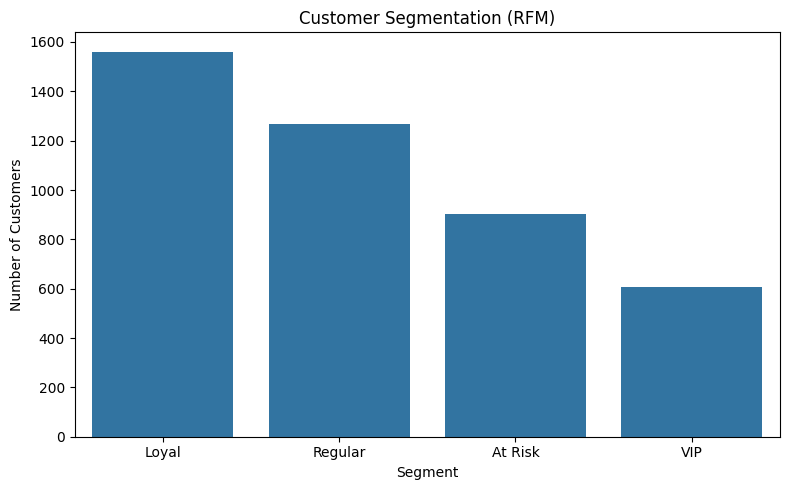

In [55]:
#Visualize Segments 
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.countplot(data=rfm, x='Segment', order=rfm['Segment'].value_counts().index)

plt.title('Customer Segmentation (RFM)')
plt.xlabel('Segment')
plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

<Axes: title={'center': 'Customer Segments Distribution'}, ylabel='count'>

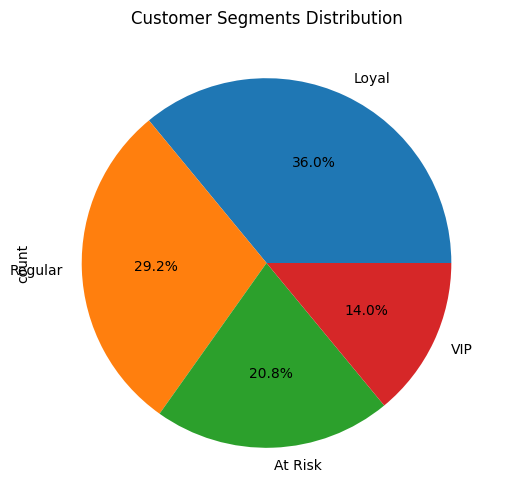

In [62]:
#PIE CHART 
rfm['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(7,6),
    title='Customer Segments Distribution'
)

In [63]:
rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean() 

,Recency,Frequency,Monetary
Segment,,,
At Risk,254.872647,1.208195,482.726369
Loyal,63.661755,4.704036,1964.359489
Regular,53.085241,1.385162,657.614957
VIP,7.651316,13.728618,7526.221513


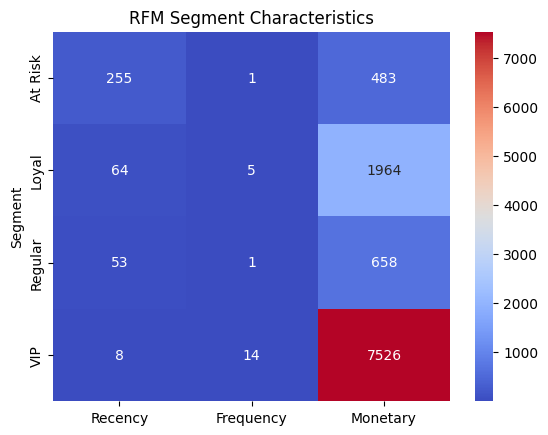

In [64]:
#Heatmap
import seaborn as sns

rfm_summary = rfm.groupby('Segment')[['Recency','Frequency','Monetary']].mean()

sns.heatmap(rfm_summary, annot=True, fmt='.0f', cmap='coolwarm')
plt.title('RFM Segment Characteristics')
plt.show()

Customers are segmented into different groups based on their purchasing behavior. VIP and Loyal customers have high frequency and monetary value, while At Risk customers show high recency, indicating inactivity.
💼 Business Recommendation:
🎯 VIP Customers → Give exclusive offers
💰 Loyal Customers → Upsell premium products
⚠️ At Risk Customers → Send discounts to re-engage
👤 Regular Customers → Improve engagement

# Market Basket Analysis (MBA)

In [77]:
#Basket
basket = (df.groupby(['InvoiceNo', 'Description'])['Quantity']
            .sum()
            .unstack()
            .fillna(0))

basket = basket > 0   # boolean

In [78]:
#Using Apriori Algorithm to identify product associations.
#Frequent Itemsets 
from mlxtend.frequent_patterns import apriori

freq = apriori(basket, min_support=0.02, use_colnames=True)

In [79]:
#Association Rules
from mlxtend.frequent_patterns import association_rules

rules = association_rules(freq, metric='lift', min_threshold=1)

In [81]:
rules[['antecedents','consequents','support','confidence','lift']].head(10)

,antecedents,consequents,support,confidence,lift
0,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE GREEN),0.028593,0.604333,14.197612
1,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED ),0.028593,0.671736,14.197612
2,(ALARM CLOCK BAKELIKE PINK),(ALARM CLOCK BAKELIKE RED ),0.021364,0.646003,13.653725
3,(ALARM CLOCK BAKELIKE RED ),(ALARM CLOCK BAKELIKE PINK),0.021364,0.451539,13.653725
4,(SPACEBOY LUNCH BOX ),(DOLLY GIRL LUNCH BOX),0.022874,0.602273,18.122934
5,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX ),0.022874,0.688312,18.122934
6,(GARDENERS KNEELING PAD CUP OF TEA ),(GARDENERS KNEELING PAD KEEP CALM ),0.024978,0.729134,17.877282
7,(GARDENERS KNEELING PAD KEEP CALM ),(GARDENERS KNEELING PAD CUP OF TEA ),0.024978,0.612434,17.877282
8,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.024817,0.827338,22.193256
9,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.024817,0.665702,22.193256


# Cohort (Retention)

In [82]:
#Create Cohort (First Purchase Month)
# Create Invoice Month
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')

# Create Cohort Month (first purchase of each customer)
df['CohortMonth'] = df.groupby('CustomerID')['InvoiceDate'] \
                      .transform('min') \
                      .dt.to_period('M')

In [83]:
#. Create Cohort Index (Month difference)
def get_month_diff(df):
    return (df['InvoiceMonth'].dt.year - df['CohortMonth'].dt.year) * 12 + \
           (df['InvoiceMonth'].dt.month - df['CohortMonth'].dt.month)

df['CohortIndex'] = get_month_diff(df)

In [84]:
#Create Cohort Table
cohort_data = df.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'] \
                .nunique() \
                .reset_index()

cohort_pivot = cohort_data.pivot(index='CohortMonth', 
                                 columns='CohortIndex', 
                                 values='CustomerID')

In [85]:
#Calculate Retention Rate
cohort_size = cohort_pivot.iloc[:, 0]

retention = cohort_pivot.divide(cohort_size, axis=0)

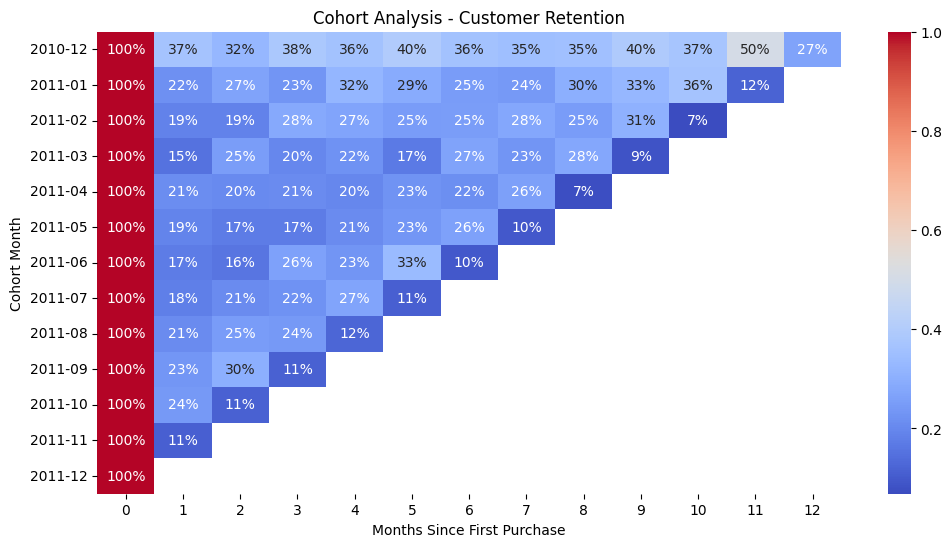

In [86]:
#Visualize (Heatmap)
plt.figure(figsize=(12, 6))
sns.heatmap(retention, 
            annot=True, 
            fmt=".0%", 
            cmap="coolwarm")

plt.title("Cohort Analysis - Customer Retention")
plt.ylabel("Cohort Month")
plt.xlabel("Months Since First Purchase")
plt.show()

## Summary

The cohort analysis reveals a business with a strong "early adopter" base but a significant struggle with immediate customer churn.

Exceptional First Cohort: The December 2010 group is the most loyal, likely consisting of "brand fans" or high-value early adopters who show a unique 50% re-engagement spike at the 11-month mark.

The "Month 1" Crisis: There is a universal and drastic drop-off immediately after the first purchase. Most cohorts lose 75% to 85% of their customers within the first 30 days.

Declining Acquisition Quality: Newer cohorts (late 2011) are showing weaker initial retention than older ones, suggesting that recent marketing efforts may be attracting "one-and-done" shoppers rather than long-term users.

Stabilization Point: If a customer stays past month 3, they enter a "stable zone" where retention levels out between 15% and 25%, forming the reliable core of the business.

## Conclusion
The data indicates a leaky bucket problem at the top of the funnel. While the business is successful at acquiring customers, it is failing to "hook" them immediately after their first experience.

The December 2010 cohort proves that high retention is possible for this brand, but the newer cohorts are trending in the wrong direction. To ensure long-term growth, the business should shift its focus from pure acquisition to post-purchase engagement, specifically targeting the "Month 1" window to prevent the initial mass exodus of users.


 # Business Recommendations
 
1. Customer Strategy
* Target high-value customers with personalized offers
* Re-engage inactive customers using email campaigns


2. Product Strategy
* Bundle frequently purchased products
* Promote high-margin items


### Sales Strategy
* Increase marketing during peak seasons
* Offer discounts during low-demand periods.

 


 
